# 30-Min Glucose Forecasting: Stronger Personalized No-CGM Model

This notebook focuses on improving **no-CGM deployment accuracy** while keeping leakage controls strict.

## Goal
Compare three variants across users:
1. **General no-CGM (leave-one-user-out)**
2. **Personalized no-CGM (improved)**: user-weighted training + per-user residual calibration
3. **Personalized + CGM history** (upper-bound assisted setting)

## Rules enforced
- Strict **time-based split** per user (first 80% train, last 20% test)
- No leakage: rolling features are past-only via `shift(1)`
- Target is future CGM glucose: `y_30 = glucose.shift(-6)` (6 x 5-minute steps)
- No-CGM variants exclude glucose-derived predictors at both train and test


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

PROJECT_DIR = Path('.')
DATA_DIR = PROJECT_DIR / 'data' / 'HUPA-UCM Diabetes Dataset' / 'Preprocessed'

csv_files = sorted(DATA_DIR.glob('*.csv'))
assert csv_files, f'No preprocessed CSV files found in {DATA_DIR.resolve()}'

parts = []
for f in csv_files:
    d = pd.read_csv(f, sep=';')
    d['time'] = pd.to_datetime(d['time'])
    d['user_id'] = f.stem
    parts.append(d)

df = pd.concat(parts, ignore_index=True).sort_values(['user_id', 'time']).reset_index(drop=True)

for c in ['glucose','calories','heart_rate','steps','basal_rate','bolus_volume_delivered','carb_input']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print('Users:', df['user_id'].nunique(), '| Rows:', len(df))


Users: 25 | Rows: 309392


In [2]:
# Feature engineering (5-minute cadence, 30-minute horizon)
CADENCE_MIN = 5
H_MIN = 30
H_STEPS = H_MIN // CADENCE_MIN
W30, W60, W120 = 6, 12, 24


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def add_time_since_event(g, col, out_col):
    event = g[col].fillna(0).to_numpy() > 0
    idx = np.where(event, np.arange(len(g)), np.nan)
    last_idx = pd.Series(idx).ffill().to_numpy()
    delta = np.arange(len(g)) - last_idx
    delta[np.isnan(last_idx)] = np.nan
    g[out_col] = delta * CADENCE_MIN


def build_features(g):
    g = g.sort_values('time').copy()

    mins = g['time'].dt.hour * 60 + g['time'].dt.minute
    angle = 2 * np.pi * mins / (24 * 60)
    g['tod_sin'] = np.sin(angle)
    g['tod_cos'] = np.cos(angle)
    g['dow'] = g['time'].dt.dayofweek
    g['is_weekend'] = (g['dow'] >= 5).astype(int)

    # Raw current non-CGM signals
    g['hr_now'] = g['heart_rate']
    g['steps_now'] = g['steps']
    g['cal_now'] = g['calories']
    g['carb_now'] = g['carb_input']
    g['bolus_now'] = g['bolus_volume_delivered']
    g['basal_now'] = g['basal_rate']

    # Past-only rolling stats
    g['hr_mean_30'] = g['heart_rate'].shift(1).rolling(W30).mean()
    g['hr_std_30'] = g['heart_rate'].shift(1).rolling(W30).std()
    g['steps_sum_30'] = g['steps'].shift(1).rolling(W30).sum()
    g['steps_sum_60'] = g['steps'].shift(1).rolling(W60).sum()
    g['cal_sum_30'] = g['calories'].shift(1).rolling(W30).sum()
    g['cal_sum_60'] = g['calories'].shift(1).rolling(W60).sum()
    g['carb_sum_60'] = g['carb_input'].shift(1).rolling(W60).sum()
    g['carb_sum_120'] = g['carb_input'].shift(1).rolling(W120).sum()
    g['bolus_sum_30'] = g['bolus_volume_delivered'].shift(1).rolling(W30).sum()
    g['bolus_sum_60'] = g['bolus_volume_delivered'].shift(1).rolling(W60).sum()
    g['basal_mean_30'] = g['basal_rate'].shift(1).rolling(W30).mean()

    # Simple lag features (past-only)
    for lag in [1, 3, 6, 12]:
        g[f'hr_lag_{lag}'] = g['heart_rate'].shift(lag)
        g[f'steps_lag_{lag}'] = g['steps'].shift(lag)
        g[f'cal_lag_{lag}'] = g['calories'].shift(lag)
        g[f'carb_lag_{lag}'] = g['carb_input'].shift(lag)
        g[f'bolus_lag_{lag}'] = g['bolus_volume_delivered'].shift(lag)

    # Time since events
    add_time_since_event(g, 'carb_input', 'mins_since_carb')
    add_time_since_event(g, 'bolus_volume_delivered', 'mins_since_bolus')

    # CGM-history features for assisted personalized variant only
    g['g_now'] = g['glucose']
    g['g_mean_30'] = g['glucose'].shift(1).rolling(W30).mean()
    g['g_std_30'] = g['glucose'].shift(1).rolling(W30).std()

    # Prediction target: future glucose at t+30min
    g['y_30'] = g['glucose'].shift(-H_STEPS)
    return g

feat = df.groupby('user_id', group_keys=False).apply(build_features).reset_index(drop=True)

features_no_cgm = [
    'tod_sin', 'tod_cos', 'dow', 'is_weekend',
    'hr_now', 'steps_now', 'cal_now', 'carb_now', 'bolus_now', 'basal_now',
    'hr_mean_30', 'hr_std_30',
    'steps_sum_30', 'steps_sum_60',
    'cal_sum_30', 'cal_sum_60',
    'carb_sum_60', 'carb_sum_120',
    'bolus_sum_30', 'bolus_sum_60',
    'basal_mean_30',
    'mins_since_carb', 'mins_since_bolus',
    'hr_lag_1', 'hr_lag_3', 'hr_lag_6', 'hr_lag_12',
    'steps_lag_1', 'steps_lag_3', 'steps_lag_6', 'steps_lag_12',
    'cal_lag_1', 'cal_lag_3', 'cal_lag_6', 'cal_lag_12',
    'carb_lag_1', 'carb_lag_3', 'carb_lag_6', 'carb_lag_12',
    'bolus_lag_1', 'bolus_lag_3', 'bolus_lag_6', 'bolus_lag_12',
]

features_with_cgm = features_no_cgm + ['g_now', 'g_mean_30', 'g_std_30']

print('Feature rows:', len(feat))
print('No-CGM feature count:', len(features_no_cgm))


Feature rows: 309392
No-CGM feature count: 43


/var/folders/nk/j9j2kxxn2n157hf_gd4sf12r0000gn/T/ipykernel_79894/3762940796.py:73: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  feat = df.groupby('user_id', group_keys=False).apply(build_features).reset_index(drop=True)


In [3]:
# Model selection for the general no-CGM setup
candidates = {
    'ridge': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=8.0))
    ]),
    'hist_gbr': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', HistGradientBoostingRegressor(
            learning_rate=0.04, max_depth=8, max_iter=300, min_samples_leaf=80, random_state=42
        ))
    ])
}

users = sorted(feat['user_id'].unique())
min_train_rows = 250
min_test_rows = 150
max_pool_rows = 110000
rng = np.random.default_rng(42)


def fit_with_optional_weights(model, X, y, sample_weight=None):
    m = clone(model)
    if sample_weight is None:
        m.fit(X, y)
        return m
    if isinstance(m, Pipeline):
        last_step = m.steps[-1][0]
        m.fit(X, y, **{f'{last_step}__sample_weight': sample_weight})
    else:
        m.fit(X, y, sample_weight=sample_weight)
    return m


general_rows = []
for user in users:
    u = feat[feat['user_id'] == user].dropna(subset=['y_30']).sort_values('time').reset_index(drop=True)
    if len(u) < (min_train_rows + min_test_rows):
        continue

    cut = int(len(u) * 0.8)
    u_train, u_test = u.iloc[:cut], u.iloc[cut:]
    if len(u_train) < min_train_rows or len(u_test) < min_test_rows:
        continue

    pool = feat[feat['user_id'] != user].dropna(subset=['y_30'])
    if len(pool) > max_pool_rows:
        idx = rng.choice(pool.index.to_numpy(), size=max_pool_rows, replace=False)
        pool = pool.loc[idx]

    X_pool, y_pool = pool[features_no_cgm], pool['y_30']
    X_test, y_test = u_test[features_no_cgm], u_test['y_30'].values

    for name, model in candidates.items():
        m = fit_with_optional_weights(model, X_pool, y_pool)
        pred = m.predict(X_test)
        general_rows.append({
            'user_id': user,
            'model': name,
            'RMSE': rmse(y_test, pred),
            'MAE': mean_absolute_error(y_test, pred),
            'n_test': len(y_test)
        })

general_df = pd.DataFrame(general_rows)
agg = (general_df
       .assign(RMSE_w=lambda d: d['RMSE'] * d['n_test'], MAE_w=lambda d: d['MAE'] * d['n_test'])
       .groupby('model', as_index=False)
       .agg(total_n=('n_test', 'sum'), RMSE_w=('RMSE_w', 'sum'), MAE_w=('MAE_w', 'sum')))
agg['RMSE'] = agg['RMSE_w'] / agg['total_n']
agg['MAE'] = agg['MAE_w'] / agg['total_n']
agg = agg[['model', 'RMSE', 'MAE', 'total_n']].sort_values('RMSE').reset_index(drop=True)

best_model_name = agg.iloc[0]['model']
best_template = candidates[best_model_name]

print('Best general model:', best_model_name)
display(agg.round(3))


Best general model: ridge


,model,RMSE,MAE,total_n
0,ridge,60.138,49.453,61858
1,hist_gbr,60.250,49.113,61858


In [4]:
# Final 3-variant per-user evaluation with stronger personalized no-CGM
rows = []

for user in users:
    u = feat[feat['user_id'] == user].dropna(subset=['y_30']).sort_values('time').reset_index(drop=True)
    if len(u) < (min_train_rows + min_test_rows):
        continue

    cut = int(len(u) * 0.8)
    u_train, u_test = u.iloc[:cut].copy(), u.iloc[cut:].copy()
    if len(u_train) < min_train_rows or len(u_test) < min_test_rows:
        continue

    y_test = u_test['y_30'].values

    # 1) General no-CGM (leave-one-user-out)
    pool_no_user = feat[feat['user_id'] != user].dropna(subset=['y_30'])
    if len(pool_no_user) > max_pool_rows:
        idx = rng.choice(pool_no_user.index.to_numpy(), size=max_pool_rows, replace=False)
        pool_no_user = pool_no_user.loc[idx]

    m_general = fit_with_optional_weights(best_template, pool_no_user[features_no_cgm], pool_no_user['y_30'])
    pred_general = m_general.predict(u_test[features_no_cgm])

    # 2) Personalized no-CGM (improved)
    #    a) user-weighted training data
    #    b) per-user residual calibrator on user train split only
    pool_plus_user_no_cgm = pd.concat([
        feat[feat['user_id'] != user].dropna(subset=['y_30']),
        u_train.dropna(subset=['y_30'])
    ], ignore_index=True)
    if len(pool_plus_user_no_cgm) > max_pool_rows:
        idx = rng.choice(pool_plus_user_no_cgm.index.to_numpy(), size=max_pool_rows, replace=False)
        pool_plus_user_no_cgm = pool_plus_user_no_cgm.loc[idx]

    is_user_train = (pool_plus_user_no_cgm['user_id'] == user).to_numpy().astype(float)
    sample_w = 1.0 + is_user_train * 12.0

    m_pers_base = fit_with_optional_weights(
        best_template,
        pool_plus_user_no_cgm[features_no_cgm],
        pool_plus_user_no_cgm['y_30'],
        sample_weight=sample_w
    )
    pred_pers_base_test = m_pers_base.predict(u_test[features_no_cgm])

    # Residual calibration using only user's train window and no-CGM features
    user_train_valid = u_train.dropna(subset=['y_30']).copy()
    pred_user_train = m_pers_base.predict(user_train_valid[features_no_cgm])
    residual_train = user_train_valid['y_30'].values - pred_user_train

    # Recency weighting inside user train to adapt to current physiology
    recency_w = np.linspace(0.6, 1.6, len(user_train_valid))
    calibrator = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=20.0))
    ])
    calibrator = fit_with_optional_weights(calibrator, user_train_valid[features_no_cgm], residual_train, sample_weight=recency_w)

    pred_resid_test = calibrator.predict(u_test[features_no_cgm])
    pred_pers_no_cgm = pred_pers_base_test + pred_resid_test
    pred_pers_no_cgm = np.clip(pred_pers_no_cgm, 40, 400)

    # 3) Personalized + CGM history (assisted upper-bound)
    pool_plus_user_with_cgm = pd.concat([
        feat[feat['user_id'] != user].dropna(subset=['y_30']),
        u_train.dropna(subset=['y_30'])
    ], ignore_index=True)
    if len(pool_plus_user_with_cgm) > max_pool_rows:
        idx = rng.choice(pool_plus_user_with_cgm.index.to_numpy(), size=max_pool_rows, replace=False)
        pool_plus_user_with_cgm = pool_plus_user_with_cgm.loc[idx]

    is_user_train_cgm = (pool_plus_user_with_cgm['user_id'] == user).to_numpy().astype(float)
    sample_w_cgm = 1.0 + is_user_train_cgm * 8.0

    m_pers_cgm = fit_with_optional_weights(
        best_template,
        pool_plus_user_with_cgm[features_with_cgm],
        pool_plus_user_with_cgm['y_30'],
        sample_weight=sample_w_cgm
    )
    pred_pers_with_cgm = m_pers_cgm.predict(u_test[features_with_cgm])
    pred_pers_with_cgm = np.clip(pred_pers_with_cgm, 40, 400)

    rows.append({
        'user_id': user,
        'general_no_cgm_rmse': rmse(y_test, pred_general),
        'personalized_no_cgm_rmse': rmse(y_test, pred_pers_no_cgm),
        'personalized_with_cgm_rmse': rmse(y_test, pred_pers_with_cgm),
        'general_no_cgm_mae': mean_absolute_error(y_test, pred_general),
        'personalized_no_cgm_mae': mean_absolute_error(y_test, pred_pers_no_cgm),
        'personalized_with_cgm_mae': mean_absolute_error(y_test, pred_pers_with_cgm),
        'n_test': len(y_test)
    })

personal_cmp = pd.DataFrame(rows)

weighted_general_rmse = np.average(personal_cmp['general_no_cgm_rmse'], weights=personal_cmp['n_test'])
weighted_pers_no_cgm_rmse = np.average(personal_cmp['personalized_no_cgm_rmse'], weights=personal_cmp['n_test'])
weighted_pers_with_cgm_rmse = np.average(personal_cmp['personalized_with_cgm_rmse'], weights=personal_cmp['n_test'])

weighted_general_mae = np.average(personal_cmp['general_no_cgm_mae'], weights=personal_cmp['n_test'])
weighted_pers_no_cgm_mae = np.average(personal_cmp['personalized_no_cgm_mae'], weights=personal_cmp['n_test'])
weighted_pers_with_cgm_mae = np.average(personal_cmp['personalized_with_cgm_mae'], weights=personal_cmp['n_test'])

summary = pd.DataFrame([
    {'Variant': 'General no-CGM (LOUO)', 'RMSE': weighted_general_rmse, 'MAE': weighted_general_mae},
    {'Variant': 'Personalized no-CGM (improved)', 'RMSE': weighted_pers_no_cgm_rmse, 'MAE': weighted_pers_no_cgm_mae},
    {'Variant': 'Personalized + CGM history', 'RMSE': weighted_pers_with_cgm_rmse, 'MAE': weighted_pers_with_cgm_mae},
])

display(summary.round(3))
print('Users evaluated:', len(personal_cmp))
print('Personalized no-CGM improved users:', int((personal_cmp['personalized_no_cgm_rmse'] < personal_cmp['general_no_cgm_rmse']).sum()), '/', len(personal_cmp))


/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['mins_since_bolus']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['mins_since_bolus']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['mins_since_carb' 'mins_since_bolus']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['mins_since_carb' 'mins_since_bolus']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['mins_since_carb' 'mins_since_bolus']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['mins_since_carb' 'mins_since_bolus']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['mins_since_carb']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['mins_since_carb']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,Variant,RMSE,MAE
0,General no-CGM (LOUO),59.935,49.374
1,Personalized no-CGM (improved),53.921,43.598
2,Personalized + CGM history,16.158,11.555


Users evaluated: 25
Personalized no-CGM improved users: 14 / 25


/var/folders/nk/j9j2kxxn2n157hf_gd4sf12r0000gn/T/ipykernel_79894/421310056.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Group', y='RMSE', order=order,


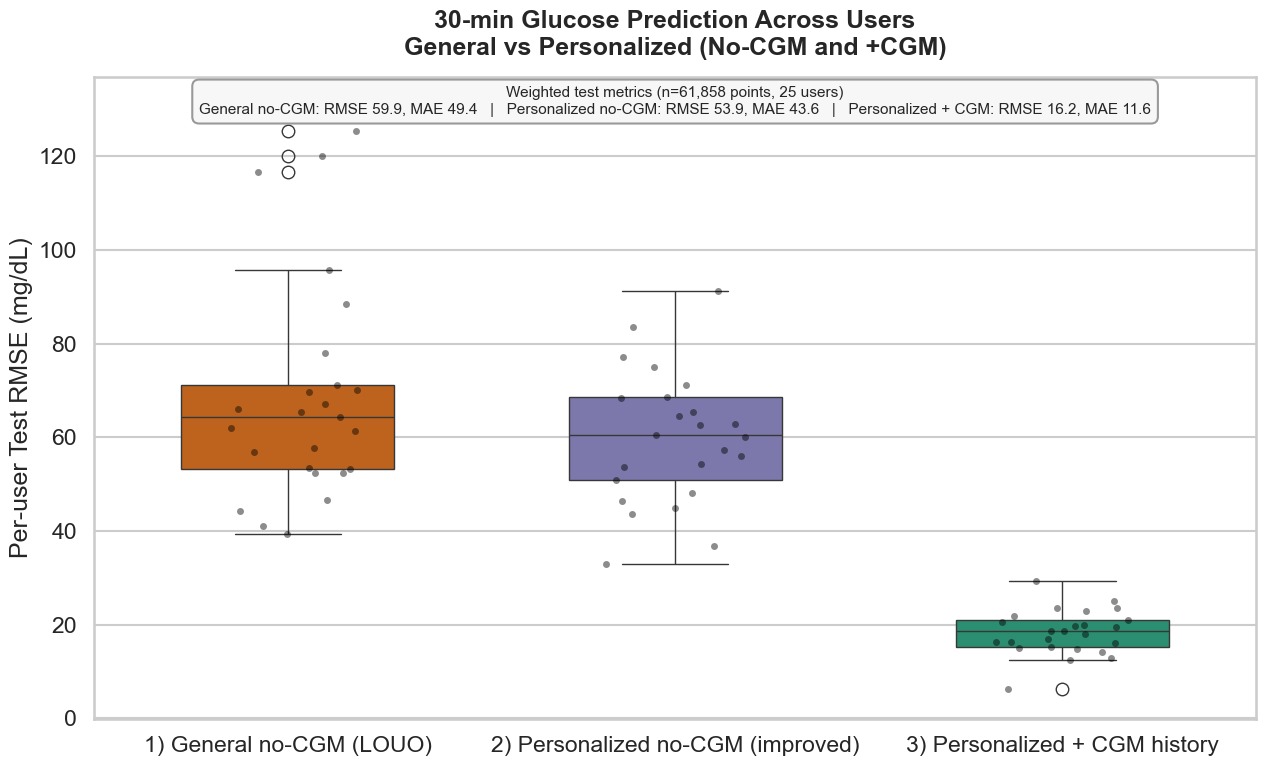

Saved: /Users/grantrooney/Documents/Projects/03_Glucose ML Estimator/reddit_glucose_30m_boxplot_3groups.png


In [5]:
# 3-group boxplot
plot_df = pd.concat([
    personal_cmp[['user_id', 'general_no_cgm_rmse']].rename(columns={'general_no_cgm_rmse': 'RMSE'}).assign(Group='1) General no-CGM (LOUO)'),
    personal_cmp[['user_id', 'personalized_no_cgm_rmse']].rename(columns={'personalized_no_cgm_rmse': 'RMSE'}).assign(Group='2) Personalized no-CGM (improved)'),
    personal_cmp[['user_id', 'personalized_with_cgm_rmse']].rename(columns={'personalized_with_cgm_rmse': 'RMSE'}).assign(Group='3) Personalized + CGM history')
], ignore_index=True)

order = [
    '1) General no-CGM (LOUO)',
    '2) Personalized no-CGM (improved)',
    '3) Personalized + CGM history'
]

sns.set_theme(style='whitegrid', context='talk')
fig, ax = plt.subplots(figsize=(13, 8))

sns.boxplot(data=plot_df, x='Group', y='RMSE', order=order,
            palette=['#D95F02', '#7570B3', '#1B9E77'], width=0.55, ax=ax)
sns.stripplot(data=plot_df, x='Group', y='RMSE', order=order,
              color='black', alpha=0.45, size=5, jitter=0.18, ax=ax)

ax.set_title('30-min Glucose Prediction Across Users\nGeneral vs Personalized (No-CGM and +CGM)', pad=16, weight='bold')
ax.set_xlabel('')
ax.set_ylabel('Per-user Test RMSE (mg/dL)')

headline = (
    f"Weighted test metrics (n={int(personal_cmp['n_test'].sum()):,} points, {len(personal_cmp)} users)\n"
    f"General no-CGM: RMSE {weighted_general_rmse:.1f}, MAE {weighted_general_mae:.1f}   |   "
    f"Personalized no-CGM: RMSE {weighted_pers_no_cgm_rmse:.1f}, MAE {weighted_pers_no_cgm_mae:.1f}   |   "
    f"Personalized + CGM: RMSE {weighted_pers_with_cgm_rmse:.1f}, MAE {weighted_pers_with_cgm_mae:.1f}"
)
ax.text(0.5, 0.985, headline, transform=ax.transAxes, ha='center', va='top', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.45', facecolor='#F7F7F7', edgecolor='#999999'))

plt.tight_layout()
out_png = PROJECT_DIR / 'results' / 'figures' / 'reddit_glucose_30m_boxplot_3groups.png'
plt.savefig(out_png, dpi=360, bbox_inches='tight')
plt.show()

print('Saved:', out_png.resolve())


## Interpretation

- **General no-CGM** is the cold-start baseline for people without CGM at inference.
- **Personalized no-CGM (improved)** uses user-weighted training + residual calibration and is the main deployment target.
- **Personalized + CGM history** remains an upper-bound assisted setting.

If personalized no-CGM gains are still modest, that indicates a true information ceiling in non-CGM signals rather than just model underfitting.
